<a href="https://colab.research.google.com/github/dalmasm/AI/blob/Data-Science/AI_Engineer_2025_Pytorch_Basics_Linear_Regressions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Engineer 2025

## Objetivo
Entender las bases de Pytorch, como definir una red neuronal sin activation functions para resolver un problema lineal

### Detalles
- Este notebook muestra un modelo basico lineal usando data sintetica

### Referencia
Ver clase 25

### Consultas
albertcapacitaciondigital@gmail.com

In [ ]:
import torch  # Importa la biblioteca PyTorch para construir y entrenar modelos de redes neuronales
import torch.nn as nn  # Importa el módulo nn de PyTorch, que contiene clases para construir capas y modelos de redes neuronales
import torch.optim as optim  # Importa el módulo optim de PyTorch, que contiene optimizadores para ajustar los parámetros del modelo
import matplotlib.pyplot as plt  # Importa la biblioteca Matplotlib para crear visualizaciones y gráficos

In [ ]:
# Detecta el dispositivo (GPU si está disponible, de lo contrario, CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Determina si una GPU está disponible y asigna el dispositivo en consecuencia
print(f"Usando el dispositivo: {device}")  # Imprime el dispositivo que se utilizará para el entrenamiento (CPU o GPU)


Usando el dispositivo: cpu


In [ ]:

# Genera 100 valores aleatorios de x entre 0 y 10
torch.manual_seed(42) # Establece la semilla para la reproduccion de los mismos datos
x_torch = torch.rand(100, 1) * 10  # Crea un tensor de PyTorch de 100 filas y 1 columna con valores aleatorios entre 0 y 1, luego multiplica por 10 para obtener valores entre 0 y 10
y_torch = 3 * x_torch + 5 + torch.randn(100, 1) * 2  # Crea un tensor de PyTorch para los valores de y basados en una relación lineal con x, agregando ruido aleatorio

# Mueve los datos al dispositivo seleccionado
x_torch, y_torch = x_torch.to(device), y_torch.to(device)  # Mueve los tensores x_torch e y_torch al dispositivo especificado (CPU o GPU)

In [ ]:
# Divide en conjuntos de entrenamiento (80%) y prueba (20%)
train_size = int(0.8 * len(x_torch))  # Calcula el tamaño del conjunto de entrenamiento (80% del conjunto de datos total)
x_train, y_train = x_torch[:train_size], y_torch[:train_size]  # Crea los tensores de entrenamiento x_train e y_train tomando las primeras 'train_size' filas de x_torch e y_torch
x_test, y_test = x_torch[train_size:], y_torch[train_size:]  # Crea los tensores de prueba x_test e y_test tomando las filas restantes de x_torch e y_torch

In [ ]:
# Define el modelo de regresión lineal
class LinearRegressionModel(nn.Module):  # Define una clase llamada LinearRegressionModel que hereda de nn.Module
    def __init__(self):  # Define el constructor de la clase
        super().__init__()  # Llama al constructor de la clase padre (nn.Module)
        self.linear = nn.Linear(1, 1)  # Define una hidden layer con 1 entrada y 1 salida

    def forward(self, x):  # Define el método forward, que define cómo se realiza el cálculo en el modelo
        return self.linear(x)  # Pasa la entrada x a través de la capa lineal y devuelve la salida

In [ ]:
# Inicializa el modelo
model = LinearRegressionModel()  # Crea una instancia de la clase LinearRegressionModel
model.to(device)  # Mueve el modelo al dispositivo especificado (CPU o GPU)

LinearRegressionModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

In [ ]:
# Define la función de pérdida (Error Cuadrático Medio) y el optimizador (Adam)
criterion = nn.MSELoss()  # Define la función de pérdida como Mean Squared Error (MSE)
#Learning rate = 0.01
optimizer = optim.Adam(model.parameters(), lr=0.01)  # Define el optimizador como Adam, pasando los parámetros del modelo y la tasa de aprendizaje

In [ ]:
# Loop de entrenamiento
num_epochs = 300  # Define el número de épocas de entrenamiento
loss_history = []  # Inicializa una lista para almacenar el historial de pérdidas

for epoch in range(num_epochs):  # Itera sobre el número de épocas
    model.train()  # Establece el modelo en modo de entrenamiento

    # Paso hacia adelante
    y_pred = model(x_train)  # Realiza un paso hacia adelante, pasando los datos de entrenamiento x_train a través del modelo para obtener predicciones y_pred
    loss = criterion(y_pred, y_train)  # Calcula la pérdida comparando las predicciones y_pred con los valores reales y_train

    # Paso hacia atrás
    optimizer.zero_grad()  # Pone a cero los gradientes de los parámetros del modelo
    loss.backward()  # Realiza un paso hacia atrás para calcular los gradientes de la pérdida con respecto a los parámetros del modelo
    optimizer.step()  # Actualiza los parámetros del modelo utilizando el optimizador

    # Almacena la pérdida para graficar
    loss_history.append(loss.item())  # Agrega la pérdida actual a la lista de historial de pérdidas

    # Imprime la pérdida cada 10 épocas
    if (epoch + 1) % 10 == 0:  # Comprueba si el número de época actual es divisible por 10
        print(f"Época {epoch+1}/{num_epochs}, Pérdida: {loss.item():.4f}")  # Imprime el número de época actual y la pérdida actual

Época 10/300, Pérdida: 460.1387
Época 20/300, Pérdida: 431.0751
Época 30/300, Pérdida: 403.2435
Época 40/300, Pérdida: 376.7063
Época 50/300, Pérdida: 351.4807
Época 60/300, Pérdida: 327.5546
Época 70/300, Pérdida: 304.8996
Época 80/300, Pérdida: 283.4790
Época 90/300, Pérdida: 263.2528
Época 100/300, Pérdida: 244.1795
Época 110/300, Pérdida: 226.2171
Época 120/300, Pérdida: 209.3233
Época 130/300, Pérdida: 193.4565
Época 140/300, Pérdida: 178.5747
Época 150/300, Pérdida: 164.6368
Época 160/300, Pérdida: 151.6018
Época 170/300, Pérdida: 139.4294
Época 180/300, Pérdida: 128.0797
Época 190/300, Pérdida: 117.5133
Época 200/300, Pérdida: 107.6918
Época 210/300, Pérdida: 98.5772
Época 220/300, Pérdida: 90.1324
Época 230/300, Pérdida: 82.3212
Época 240/300, Pérdida: 75.1082
Época 250/300, Pérdida: 68.4589
Época 260/300, Pérdida: 62.3401
Época 270/300, Pérdida: 56.7191
Época 280/300, Pérdida: 51.5648
Época 290/300, Pérdida: 46.8469
Época 300/300, Pérdida: 42.5363


In [ ]:
# Mueve los datos de prueba de vuelta a la CPU para la
# Matplotlib no soporta tensors en GPU
x_train_cpu, y_train_cpu = x_train.cpu(), y_train.cpu()  # Mueve los tensores de entrenamiento x_train e y_train de vuelta a la CPU
x_test_cpu, y_test_cpu = x_test.cpu(), y_test.cpu()  # Mueve los tensores de prueba x_test e y_test de vuelta a la CPU

In [ ]:
# Establece el modelo en modo de evaluación para la prueba
model.eval()  # Establece el modelo en modo de evaluación
with torch.no_grad():  # Desactiva el cálculo de gradientes durante la prueba
    y_pred_cpu = model(x_test.to(device)).detach().cpu()  # Realiza predicciones en los datos de prueba, mueve los resultados a la CPU y los separa del gráfico de cálculo


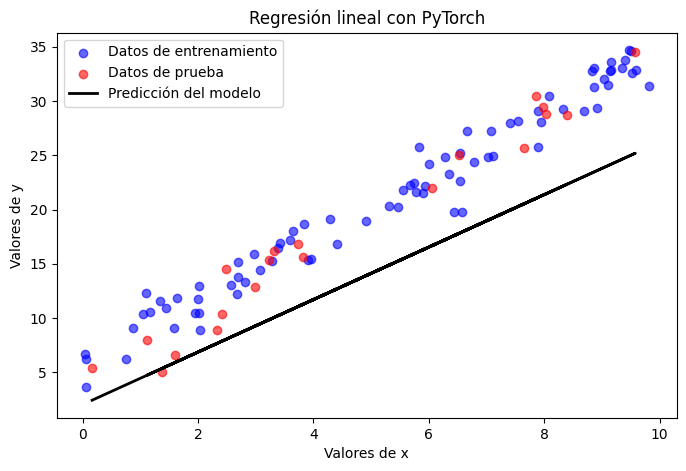

In [ ]:
# Grafica los datos y el modelo entrenado
plt.figure(figsize=(8, 5))  # Crea una nueva figura para el gráfico con un tamaño específico
plt.scatter(x_train_cpu, y_train_cpu, label="Datos de entrenamiento", color="blue", alpha=0.6)  # Grafica los datos de entrenamiento como puntos azules
plt.scatter(x_test_cpu, y_test_cpu, label="Datos de prueba", color="red", alpha=0.6)  # Grafica los datos de prueba como puntos rojos
plt.plot(x_test_cpu, y_pred_cpu, label="Predicción del modelo", color="black", linewidth=2)  # Grafica las predicciones del modelo como una línea negra
plt.xlabel("Valores de x")  # Establece la etiqueta del eje x
plt.ylabel("Valores de y")  # Establece la etiqueta del eje y
plt.title("Regresión lineal con PyTorch")  # Establece el título del gráfico
plt.legend()  # Muestra la leyenda
plt.show()  # Muestra el gráfico

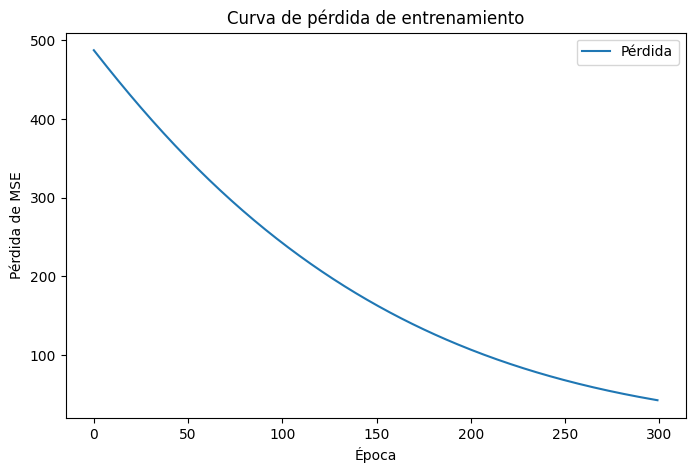

In [ ]:
# Grafica la curva de pérdida
plt.figure(figsize=(8, 5))  # Crea una nueva figura para el gráfico con un tamaño específico
plt.plot(loss_history, label="Pérdida")  # Grafica el historial de pérdidas
plt.xlabel("Época")  # Establece la etiqueta del eje x
plt.ylabel("Pérdida de MSE")  # Establece la etiqueta del eje y
plt.title("Curva de pérdida de entrenamiento")  # Establece el título del gráfico
plt.legend()  # Muestra la leyenda
plt.show()  # Muestra el gráfico